In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import glob
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar

maxz=200
argofolder = '../data/ARGO/'

In [4]:
extent_gyre =[141,145,-63,-61.5]
extent = [139, 150,-68,-65.5]
wider_area = [130, 160, -68, -60]
elevation_ = GEBCO(coarsen_factor=1).ds.elevation
elevation = elevation_.sel(latitude = slice(wider_area[2], wider_area[3]), longitude = slice(wider_area[0],wider_area[1]))

In [5]:
pax200 = np.arange(0,202,2)
pax1000 = np.arange(0,1002,2)

In [6]:
def crop2shelf(ds,lat='lat',lon='lon'):
    ds['elevation'] = elevation.interp(latitude=ds[lat],longitude=ds[lon]).drop(['longitude','latitude'])
    return ds.where(ds.elevation > -1000,drop=True)

In [8]:
# meop200 = MEOP(extent=extent)
# meop1000 = MEOP(extent=extent)
# meop200.load_profiles_for_spira(np.arange(0,202,2))
# meop1000.load_profiles_for_spira()
meop200ds = xr.open_dataset('meop200.nc')
meop1000ds = xr.open_dataset('meop1000.nc')

In [25]:
meop200ds = crop2shelf(meop200ds)
meop1000ds = crop2shelf(meop1000ds)

In [ ]:
# meop200.ds.to_netcdf('meop200.nc')
# meop1000.ds.to_netcdf('meop1000.nc')

In [9]:
fname = '../data/qc_profile_ds_2dbar.nc'
ds = xr.open_dataset(fname).swap_dims({'n_prof':'time'})
spira1000 = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)
spira1000 = crop2shelf(spira1000)
spira200 = spira1000.sel(pres=slice(0,maxz))

/tmp/ipykernel_36039/2763227059.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds[lat],longitude=ds[lon]).drop(['longitude','latitude'])


In [10]:
# also add argo
profiles200=[]
profiles1000=[]
# also add argo
profiles=[]
for file in glob.glob(argofolder + '*nc'):
    dsa = xr.open_dataset(file)
    for t in dsa.TIME:
        if t < pd.Timestamp(2022,1,1):
            dst = dsa.sel(TIME=t)
            if (dst.LATITUDE < extent[3]) & (dst.LONGITUDE < extent[1]):
                dstn = dst.swap_dims({'DEPTH':'PRES_ADJUSTED'}).dropna(dim='PRES_ADJUSTED')
                if elevation.interp({'latitude':dstn.LATITUDE,'longitude':dstn.LONGITUDE}) > -1000:
                    if len(dstn.PRES)>0:
                        pnew = dstn.expand_dims(['TIME']).drop_vars([
     'TRAJECTORY', 'TIME_QC', 'POSITION_QC', 'DC_REFERENCE', 'DIRECTION', 'PRES_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC','PSAL_ADJUSTED_QC','PRES_CORE','PRES'
    ])
                        pnew = pnew.assign_coords(
                            LATITUDE=("TIME", [pnew.LATITUDE.values]),
                            LONGITUDE=("TIME", [pnew.LONGITUDE.values])
                        )
                        profiles200.append(pnew.interp({'PRES_ADJUSTED':pax200}))
                        profiles1000.append(pnew.interp({'PRES_ADJUSTED':pax1000}))

def mergeprofs(profiles):
    return xr.merge(profiles).rename({
    'TIME':'time',
    'LONGITUDE':'lon',
    'LATITUDE':'lat',
    'PRES_ADJUSTED':'pres',
    'TEMP_ADJUSTED':'temp',
    'PSAL_ADJUSTED':'psal'})

argo200 = mergeprofs(profiles200)
argo1000 = mergeprofs(profiles1000)

In [11]:
argo200 = crop2shelf(argo200)
argo1000 = crop2shelf(argo1000)

/tmp/ipykernel_36039/2763227059.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds[lat],longitude=ds[lon]).drop(['longitude','latitude'])
/tmp/ipykernel_36039/2763227059.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds[lat],longitude=ds[lon]).drop(['longitude','latitude'])


In [18]:
spiraargo200=xr.merge([spira200.drop_duplicates('time'),argo200])
spiraargo1000=xr.merge([spira1000.drop_duplicates('time'),argo1000])

In [26]:
ds200 = xr.merge([spiraargo200,meop200ds.drop_duplicates('time')],compat='override')
ds1000 = xr.merge([spiraargo1000,meop1000ds.drop_duplicates('time')],compat='override')


In [27]:
ds200['month'] = ds200.time.dt.month
ds1000['month'] = ds1000.time.dt.month


In [81]:
df=pd.concat([spira200.to_dataframe(),argo200.to_dataframe(),meop200ds.rename({'profile_code':'n_prof'}).to_dataframe()])

In [60]:
pres=[i[1] for i in df.index]

In [ ]:
df.reset_index().drop_duplicates(subset=['time', 'pres', 'lat', 'lon']).set_index(['n_prof', 'pres']).to_xarray()


ValueError: cannot convert a DataFrame with a non-unique MultiIndex into xarray

In [74]:
df.drop_duplicates(subset=['lat', 'lon'])

,,temp,psal,dsource,mld,asal,ctemp,rho,mlp,elevation,lon,lat,n_prof,profile_code
time,pres,,,,,,,,,,,,,
2007-02-20 23:29:59.000002,0,NaN,NaN,MEOP,65.335625,NaN,NaN,NaN,52.0,-296.920000,140.0420,-66.5560,793190.0,NaN
2007-02-21 08:39:58.999996,0,NaN,NaN,MEOP,17.820848,NaN,NaN,NaN,14.0,-96.139040,139.9780,-66.5839,793191.0,NaN
2007-02-22 08:39:58.999996,0,NaN,NaN,MEOP,49.498241,NaN,NaN,NaN,42.0,-498.969040,140.0430,-66.6646,793247.0,NaN
2007-02-22 14:19:58.999998,0,NaN,NaN,MEOP,49.498291,NaN,NaN,NaN,50.0,-364.856880,140.0340,-66.6504,793192.0,NaN
2007-02-24 02:39:58.999996,0,NaN,NaN,MEOP,49.498516,NaN,NaN,NaN,50.0,-96.825200,139.9570,-66.5818,793193.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-08 07:49:59.000000,0,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,-133.129456,141.3027,-66.6608,NaN,wd11-768-18
2019-06-08 23:09:59.000000,0,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,-128.545392,141.3139,-66.6508,NaN,wd11-768-18
2019-06-09 15:50:00.000000,0,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,-140.915600,141.3284,-66.6525,NaN,wd11-768-18


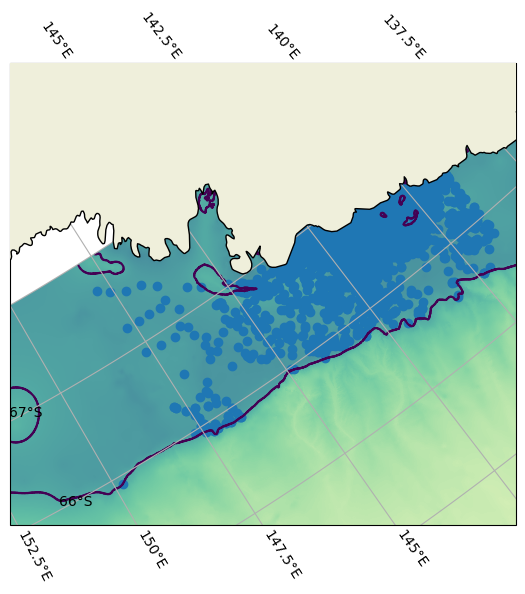

In [69]:
dsp=df[np.array(pres)==0]
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(dsp.lon,dsp.lat,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

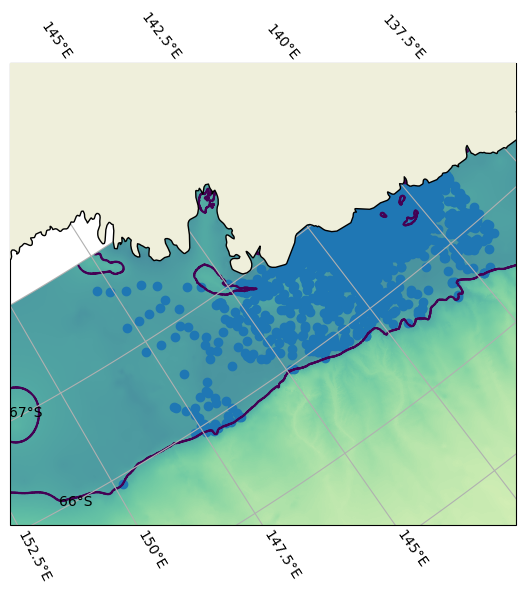

In [75]:
dsp = df.drop_duplicates(subset=['lat', 'lon'])
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(dsp.lon,dsp.lat,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

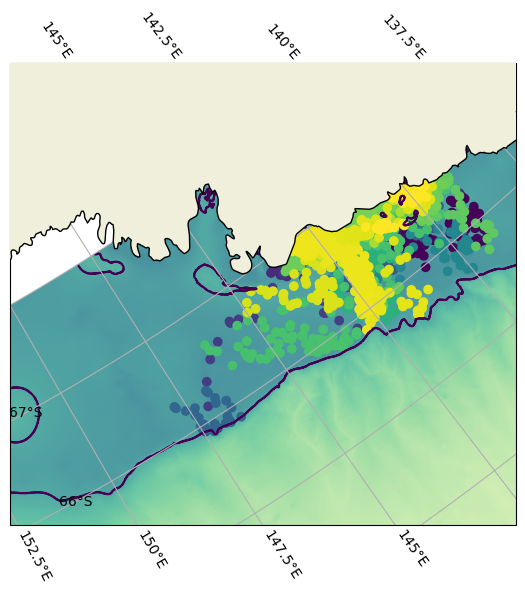

In [29]:
dsp=xr.merge([meop200ds.drop_duplicates('time'),spiraargo200],compat='override')
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(dsp.lon,dsp.lat,c=dsp.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

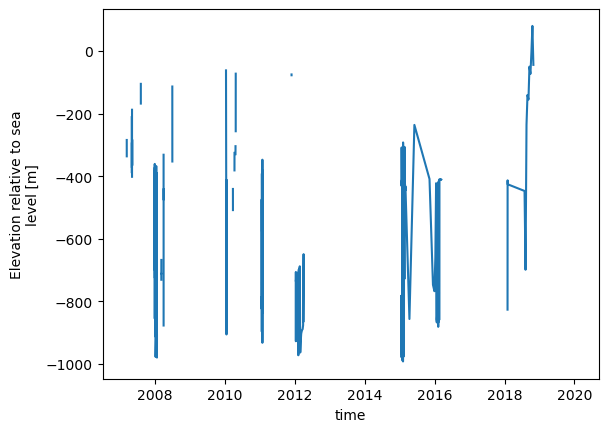

In [20]:
ds200.elevation.plot()

In [23]:
xr.merge([spira200.drop_duplicates(dim='time'),argo200],compat='override')

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1991, pres: 101)
Coordinates:
  * time     (time) datetime64[ns] 16kB 2004-10-28T21:36:00.003089408 ... 202...
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
    lon      (time) float64 16kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 16kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
    n_prof   (time) float64 16kB 5.668e+05 1.199e+05 ... 2.989e+05 8.11e+05
Data variables:
    temp     (time, pres) float64 2MB nan nan nan nan ... -0.303 -0.258 -0.199
    psal     (time, pres) float64 2MB nan nan nan nan ... 34.61 34.62 34.62
    dsource  (time) object 16kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 16kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 804kB nan nan nan nan ... 34.78 34.78 34.79
    ctemp    (time, pres) float32 804kB nan nan nan ... -0.3011 -0.2561 -0.1972
    rho      (time, pres) float32 804kB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 16kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...